In [9]:
import numpy as np
import matplotlib.pyplot as plt

In [26]:
N = 1000
# the spin is uniformly distributed between 0 and 1
Chi = np.random.uniform(0,1,N)

#te mass is normally distributed with a meanand a std
sigma = 0.02
M = np.random.normal(1,sigma,N)

In [19]:
def irreducible_mass(mass, spin):
    Mirr = mass * np.sqrt((1 + np.sqrt(1 - spin**2)) / 2)
    return Mirr

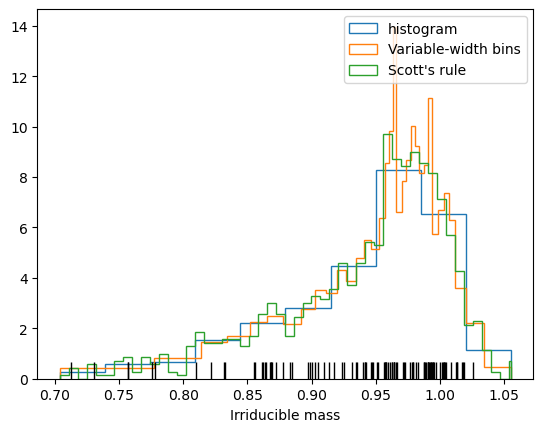

In [42]:
# irreducible mass
M_irr = irreducible_mass(M,Chi)

# plotting with an histogram
plt.hist(M_irr, density=True,histtype='step',label='histogram')
plt.xlabel('Irriducible mass')

# histogram with variable-width bin sizes
bins100 = np.append(np.sort(M_irr)[::30], np.max(M_irr))
plt.hist(M_irr, bins=bins100, density=True, histtype='step',label='Variable-width bins')
plt.xlabel('Irriducible mass')

# histogram with Soctt's rule
binsize = 3.5 * sigma / (N**(1/3))
binsS = np.append(np.arange(start=M_irr.min(), stop=M_irr.max(), step=binsize), M_irr.max())
plt.hist(M_irr, bins=binsS, density=True, histtype='step', label="Scott's rule")
plt.xlabel('Irriducible mass')

# histogram showing all the data
plt.plot(M_irr[:100], 0*M_irr[:100], '|', color='k', markersize=25)
plt.xlabel('Irriducible mass')
plt.legend()
plt.show()

In [54]:
# plot the distribution of M_irr using a KDE
from sklearn.neighbors import KernelDensity
xgrid = np.linspace(M_irr.min(),M_irr.max(),1000)

def kde_sklearn(data, bandwidth=1.0,kernel='linear'):
    kde_skl = KernelDensity(bandwidth=bandwidth,kernel=kernel)
    kde_skl.fit(data[:,np.newaxis])
    log_pdf = kde_skl.score_samples(xgrid[:,np.newaxis])
    return np.exp(log_pdf)

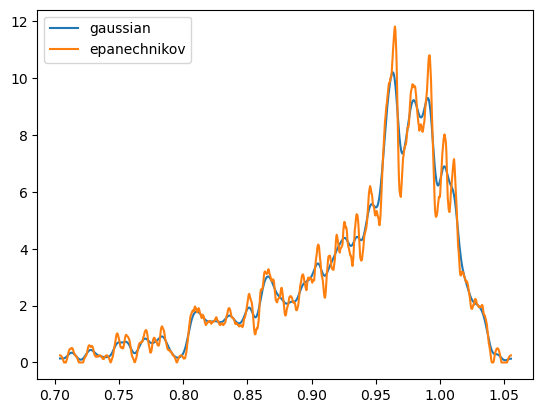

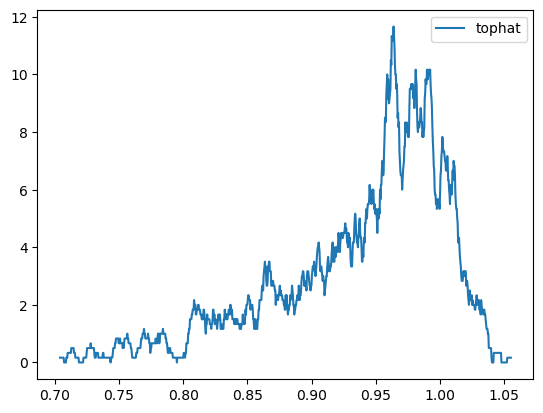

In [64]:
PDFgaussian = kde_sklearn(M_irr, bandwidth=0.003, kernel='gaussian')
plt.plot(xgrid,PDFgaussian, label='gaussian')

PDFepa = kde_sklearn(M_irr, bandwidth=0.003,kernel='epanechnikov')
plt.plot(xgrid,PDFepa, label='epanechnikov')
plt.legend()
plt.show()

PDFtophat = kde_sklearn(M_irr,bandwidth=0.003,kernel="tophat") 
plt.plot(xgrid,PDFtophat, label='tophat')
plt.legend()
plt.show()


